Field shape: (48, 48, 48)
Missing voxels: 5832  (5.3% of volume)

Training tiny 3D U-Net to inpaint the missing region...
  step    0   loss = 0.020052
  step  100   loss = 0.005575
  step  200   loss = 0.005303
  step  300   loss = 0.005366


/tmp/ipykernel_15131/4010949767.py:73: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


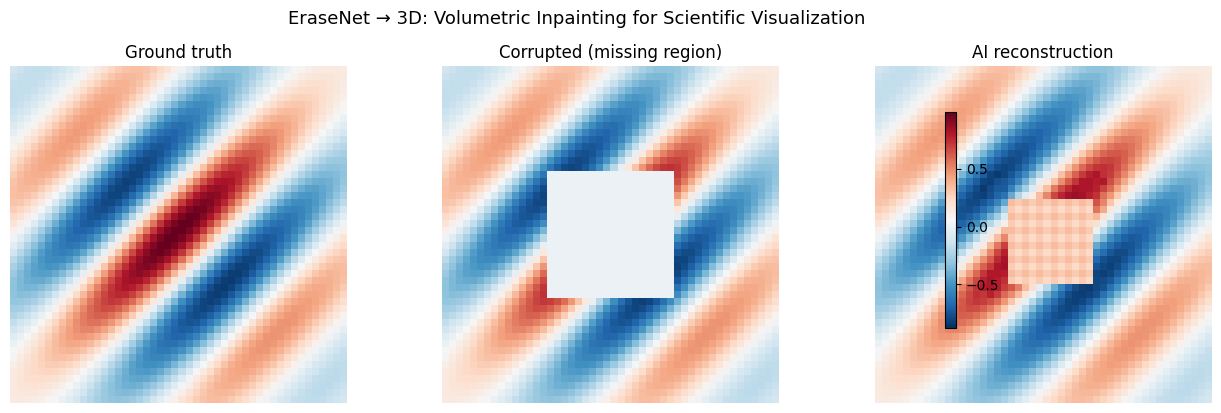


✓ Done.
  - inpainting_slices.png         (preview image, shown above)
  - erasenet_paraview_bridge.vti  (open in ParaView for volume rendering)


In [1]:
# === Setup ===
!pip install pyevtk -q

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from pyevtk.hl import imageToVTK

torch.manual_seed(42)
np.random.seed(42)

# === Step A: Generate a synthetic 3D scalar field with a "missing" region ===
# Stands in for any volumetric scientific dataset (CT scan, CFD field,
# electron density, etc.) with a corrupted region we want to recover.
N = 48
x = np.linspace(-1, 1, N)
X, Y, Z = np.meshgrid(x, x, x, indexing='ij')
ground_truth = (np.exp(-(X**2 + Y**2 + Z**2)) * np.cos(5*(X+Y+Z))).astype(np.float32)

mask = np.zeros_like(ground_truth)
mask[15:33, 15:33, 15:33] = 1.0          # cubic "missing" region
corrupted = ground_truth * (1 - mask)

print(f"Field shape: {ground_truth.shape}")
print(f"Missing voxels: {int(mask.sum())}  ({100*mask.mean():.1f}% of volume)")

# === Step B: Tiny 3D U-Net for volumetric inpainting ===
class TinyUNet3D(nn.Module):
    def __init__(self, c=16):
        super().__init__()
        self.enc1 = nn.Sequential(nn.Conv3d(2, c, 3, padding=1), nn.ReLU())
        self.enc2 = nn.Sequential(nn.Conv3d(c, 2*c, 3, padding=1, stride=2), nn.ReLU())
        self.dec1 = nn.Sequential(nn.ConvTranspose3d(2*c, c, 4, stride=2, padding=1), nn.ReLU())
        self.out  = nn.Conv3d(c, 1, 1)
    def forward(self, x):
        e1 = self.enc1(x); e2 = self.enc2(e1); d1 = self.dec1(e2)
        return self.out(d1 + e1)

device = "cuda" if torch.cuda.is_available() else "cpu"
model = TinyUNet3D().to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)

inp    = torch.from_numpy(np.stack([corrupted, mask]))[None].to(device)
tgt    = torch.from_numpy(ground_truth)[None, None].to(device)
mask_t = torch.from_numpy(mask).to(device)

print("\nTraining tiny 3D U-Net to inpaint the missing region...")
for step in range(400):
    pred = model(inp)
    loss = ((pred - tgt) ** 2 * mask_t).mean()
    opt.zero_grad(); loss.backward(); opt.step()
    if step % 100 == 0:
        print(f"  step {step:>4d}   loss = {loss.item():.6f}")

reconstructed = pred.detach().cpu().numpy()[0, 0]
final_field   = corrupted * (1 - mask) + reconstructed * mask

# === Step C: Visualize central slice of each volume ===
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
mid = N // 2
vmin, vmax = ground_truth.min(), ground_truth.max()
for ax, arr, title in zip(
    axes,
    [ground_truth[mid], corrupted[mid], final_field[mid]],
    ["Ground truth", "Corrupted (missing region)", "AI reconstruction"]
):
    im = ax.imshow(arr, cmap='RdBu_r', vmin=vmin, vmax=vmax)
    ax.set_title(title); ax.axis('off')
fig.colorbar(im, ax=axes, orientation='vertical', shrink=0.7)
plt.suptitle("EraseNet → 3D: Volumetric Inpainting for Scientific Visualization",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("inpainting_slices.png", dpi=120, bbox_inches='tight')
plt.show()

# === Step D: Export the volumes as ParaView-readable .vti ===
imageToVTK("./erasenet_paraview_bridge",
           pointData={
               "ground_truth":   ground_truth,
               "corrupted":      corrupted,
               "reconstructed":  final_field.astype(np.float32),
               "mask":           mask
           })

print("\n✓ Done.")
print("  - inpainting_slices.png         (preview image, shown above)")
print("  - erasenet_paraview_bridge.vti  (open in ParaView for volume rendering)")